# Minimal Example: Using TileZZ with Jupyter

This notebook shows a minimal example of using tilezz with a Jupyter notebook.

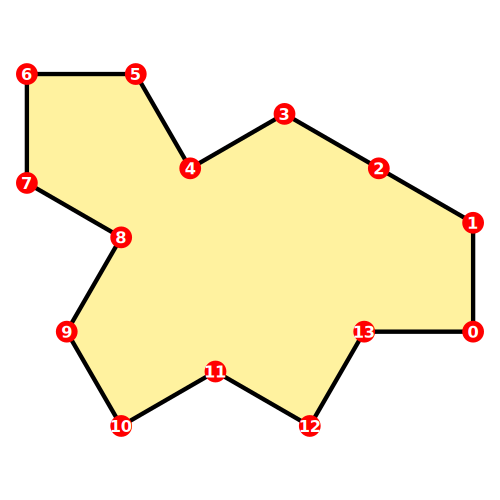

In [2]:
// Build and load the crate (with raster feature so we can also render PNGs;
// SVG works without it but PNG needs resvg + tiny-skia).
// 1(a) for the published crate:
// :dep tilezz = { version = "*", features = ["raster"] }
// 1(b) (RECOMMENDED) for the development version of this repo:
:dep tilezz = { path = "..", features = ["raster"] }

// Import what we need.
use tilezz::cyclotomic::*;
use tilezz::intgeom::rat::Rat;
use tilezz::intgeom::snake::Turtle;
use tilezz::vis::draw::{MarkerStyle, TileStyle};
use tilezz::vis::scene::{Color, Fill, Scene, Stroke, TextStyle, Viewport};

// Define a sequence of external angles. All segments have unit length,
// so this fully determines a polygon.
let external_angles: &[i8] = &[3, 2, 0, 2, -3, 2, 3, 2, -3, 2, 3, -2, 3, -2];

// Instantiate an abstract polygon over the cyclotomic ring ZZ12.
let r: Rat<ZZ12> = external_angles.try_into().unwrap();
// Trace out the polygon in the cartesian plane with the default Turtle
// (origin, facing along the +x axis).
let pts: Vec<(f64, f64)> = r.to_polyline_f64(Turtle::default());

// Build a scene with one filled tile + red vertex markers + index labels.
let mut scene: Scene = Scene::new().with_background(Color::WHITE);
scene.draw_tile(
    &pts,
    &TileStyle::filled(
        Fill::solid(Color::YELLOW.with_alpha(96)),
        Stroke::solid(Color::BLACK, 0.04),
    )
    .with_vertex_marker(MarkerStyle::filled_circle(0.2, Color::RED))
    .with_vertex_labels(TextStyle::new(0.15, Color::WHITE).bold()),
);

// Render inline as SVG. evcxr picks up the evcxr_display method.
let vp: Viewport = Viewport::square_for(500, scene.auto_bounds().unwrap(), 16);
scene.display(&vp)